# Layer Sweep â€” Feed-Forward vs Attention

Sweeps every feed-forward layer (`DenseReluDense.wo`) and every attention layer
(`SelfAttention.o` + `EncDecAttention.o`) of the judge model independently.
For each layer we train a cross-validated XGBoost classifier (PCA-reduced activations)
and record **AUC, accuracy, F1, precision, and recall**.

The two layer families are plotted separately so their signal profiles can be compared.

## Cell 1 â€” Imports

In [1]:
import sys, os, re

repo_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import roc_auc_score
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

from neuralsignal.backend.ns_backend import NSBackend

print("Imports OK")

E:\Programming\neuralsignal\neuralsignal\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Imports OK


## Cell 2 â€” Config

In [2]:
APPLICATION_NAME     = "redis"
SUB_APPLICATION_NAME = "quora_duplicates_t5_large"

GROUP_SIZE   = 50          # total scans per class
HALF         = GROUP_SIZE // 2
K_COMPONENTS = 10          # PCA dims (kept constant across layers for fair comparison)
CV_FOLDS     = 5
RANDOM_STATE = 42
EMERGENCE_THRESHOLD = 0.60  # AUC above this is "meaningful signal"

# Balanced loading: equal halves from gt=0 and gt=1 so ground_truth
# cannot act as a spurious discriminating feature.
FILTER_CORRECT_GT0      = {"ground_truth": "0", "decoded_output": {"$regex": "^Fal"}}
FILTER_CORRECT_GT1      = {"ground_truth": "1", "decoded_output": {"$regex": "^True"}}
FILTER_HALLUCINATED_GT0 = {"ground_truth": "0", "decoded_output": {"$regex": "^True"}}
FILTER_HALLUCINATED_GT1 = {"ground_truth": "1", "decoded_output": {"$regex": "^Fal"}}

## Cell 3 â€” Connect to backend & load scans

In [3]:
import tempfile
from neuralsignal.core.modules.neuralsignal_config import sdk_config

backend_cfg = sdk_config.get_backend_config()
backend_cfg["scan_cache_directory"] = tempfile.gettempdir()

cfg = {
    "application_name": APPLICATION_NAME,
    "sub_application_name": SUB_APPLICATION_NAME,
    "backend_config": backend_cfg,
}
be = NSBackend(cfg)


def load_group(be, filter_a, filter_b, n_each):
    """Load n_each scans from filter_a and n_each from filter_b, combined."""
    scans = []
    for f in [filter_a, filter_b]:
        cursor = be.query(f).limit(n_each)
        for doc in cursor:
            try:
                scans.append(be.deserialize_scan(doc))
            except Exception as e:
                print(f"  skipping {doc.get('_id')}: {e}")
    return scans


print(f"Loading correct group ({HALF} gt=0 + {HALF} gt=1) ...")
group_correct = load_group(be, FILTER_CORRECT_GT0, FILTER_CORRECT_GT1, HALF)
print(f"  loaded {len(group_correct)} scans")

print(f"Loading hallucinated group ({HALF} gt=0 + {HALF} gt=1) ...")
group_hallucinated = load_group(be, FILTER_HALLUCINATED_GT0, FILTER_HALLUCINATED_GT1, HALF)
print(f"  loaded {len(group_hallucinated)} scans")

Loading correct group (25 gt=0 + 25 gt=1) ...
  loaded 50 scans
Loading hallucinated group (25 gt=0 + 25 gt=1) ...
  loaded 50 scans


## Cell 4 â€” Layer discovery

Two helpers that inspect the first scan and return all matching layers in
forward-pass order with short display labels.

- **Feed-forward** (`DenseReluDense.wo`): output linear projection of the FF sublayer
- **Attention** (`SelfAttention.o` + `EncDecAttention.o`): SA in both stacks, CA in decoder

In [4]:
def get_ff_layers(scan):
    """Return [(layer_id, full_name, short_label), ...] for DenseReluDense.wo layers."""
    lid_to_name = scan["layer_id_to_name"]
    enc_idx = dec_idx = 0
    rows = []
    for lid in scan["layer_order"]:
        name = lid_to_name[lid]
        if "DenseReluDense.wo" not in name:
            continue
        is_enc = "encoder" in name.lower()
        m = re.search(r'\.(\d+)\.', name)
        if m:
            label = f"{'enc' if is_enc else 'dec'}.{m.group(1)}"
        else:
            if is_enc:
                label = f"enc.{enc_idx}"
                enc_idx += 1
            else:
                label = f"dec.{dec_idx}"
                dec_idx += 1
        rows.append((lid, name, label))
    return rows


def get_attn_layers(scan):
    """Return [(layer_id, full_name, short_label), ...] for all attention layers.

    Covers SelfAttention.o (encoder + decoder) and EncDecAttention.o (decoder cross-attn).
    Labels: enc.N for encoder SA, dec_sa.N for decoder SA, dec_ca.N for decoder CA.
    """
    lid_to_name = scan["layer_id_to_name"]
    enc_sa_idx = dec_sa_idx = dec_ca_idx = 0
    rows = []
    for lid in scan["layer_order"]:
        name = lid_to_name[lid]
        is_sa = "SelfAttention.o" in name
        is_ca = "EncDecAttention.o" in name
        if not (is_sa or is_ca):
            continue
        is_enc = "encoder" in name.lower()
        m = re.search(r'\.(\d+)\.', name)
        block = m.group(1) if m else None
        if is_sa and is_enc:
            label = f"enc.{block}" if block else f"enc.{enc_sa_idx}"
            enc_sa_idx += 1
        elif is_sa and not is_enc:
            label = f"dec_sa.{block}" if block else f"dec_sa.{dec_sa_idx}"
            dec_sa_idx += 1
        else:  # cross-attention
            label = f"dec_ca.{block}" if block else f"dec_ca.{dec_ca_idx}"
            dec_ca_idx += 1
        rows.append((lid, name, label))
    return rows


ff_layers   = get_ff_layers(group_correct[0])
attn_layers = get_attn_layers(group_correct[0])

print(f"Feed-forward layers  : {len(ff_layers)}")
for i, (lid, name, label) in enumerate(ff_layers):
    print(f"  [{i:>2}] {label:<12}  {name}")

print(f"\nAttention layers     : {len(attn_layers)}")
for i, (lid, name, label) in enumerate(attn_layers):
    print(f"  [{i:>2}] {label:<12}  {name}")

Feed-forward layers  : 48
  [ 0] enc.0         encoder.T5Block.T5LayerFF.DenseReluDense.wo
  [ 1] enc.1         encoder.T5Block.T5LayerFF.DenseReluDense.wo
  [ 2] enc.2         encoder.T5Block.T5LayerFF.DenseReluDense.wo
  [ 3] enc.3         encoder.T5Block.T5LayerFF.DenseReluDense.wo
  [ 4] enc.4         encoder.T5Block.T5LayerFF.DenseReluDense.wo
  [ 5] enc.5         encoder.T5Block.T5LayerFF.DenseReluDense.wo
  [ 6] enc.6         encoder.T5Block.T5LayerFF.DenseReluDense.wo
  [ 7] enc.7         encoder.T5Block.T5LayerFF.DenseReluDense.wo
  [ 8] enc.8         encoder.T5Block.T5LayerFF.DenseReluDense.wo
  [ 9] enc.9         encoder.T5Block.T5LayerFF.DenseReluDense.wo
  [10] enc.10        encoder.T5Block.T5LayerFF.DenseReluDense.wo
  [11] enc.11        encoder.T5Block.T5LayerFF.DenseReluDense.wo
  [12] enc.12        encoder.T5Block.T5LayerFF.DenseReluDense.wo
  [13] enc.13        encoder.T5Block.T5LayerFF.DenseReluDense.wo
  [14] enc.14        encoder.T5Block.T5LayerFF.DenseReluDense.wo

## Cell 5 â€” Sweep helper

Shared function used by both FF and attention sweeps.  
Returns a `dict` of `{metric: (means_array, stds_array)}` plus `labels`.

In [5]:
def extract_vector(scan, layer_id):
    """Last-token activation vector from scan outputs, shape (hidden_dim,)."""
    tensor = scan["outputs"][layer_id]
    return tensor[-1, :].float()


def build_matrix(scans, layer_id, expected_dim=None):
    vecs, skipped = [], 0
    for scan in scans:
        try:
            v = extract_vector(scan, layer_id)
            if expected_dim is not None and v.shape[0] != expected_dim:
                skipped += 1
                continue
            vecs.append(v)
        except Exception:
            skipped += 1
    return torch.stack(vecs), skipped


SCORING = ["roc_auc", "accuracy", "f1", "precision", "recall"]


def run_layer_sweep(layers, group_correct, group_hallucinated, verbose=True):
    """Run the per-layer metric sweep.

    Returns a dict with keys:
        'labels'                         list of short label strings
        'auc', 'auc_std'                 np.ndarray
        'accuracy', 'accuracy_std'
        'f1', 'f1_std'
        'precision', 'precision_std'
        'recall', 'recall_std'
    """
    cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

    labels = []
    metric_means = {m: [] for m in SCORING}
    metric_stds  = {m: [] for m in SCORING}

    for i, (lid, name, label) in enumerate(layers):
        vecs_c, _ = build_matrix(group_correct,      lid)
        vecs_h, s = build_matrix(group_hallucinated, lid, expected_dim=vecs_c.shape[1])

        X = np.vstack([vecs_c.numpy(), vecs_h.numpy()])
        y = np.array([0] * len(vecs_c) + [1] * len(vecs_h))

        k = min(K_COMPONENTS, X.shape[1], X.shape[0] - 1)
        pipe = Pipeline([
            ("pca", PCA(n_components=k, random_state=RANDOM_STATE)),
            ("clf", XGBClassifier(
                n_estimators=100,
                verbosity=0,
                random_state=RANDOM_STATE,
                eval_metric="logloss",
            )),
        ])

        results = cross_validate(
            pipe, X, y, cv=cv,
            scoring=SCORING,
            return_train_score=False,
        )

        labels.append(label)
        for m in SCORING:
            key = f"test_{m}"
            metric_means[m].append(results[key].mean())
            metric_stds[m].append(results[key].std())

        if verbose:
            auc = metric_means["roc_auc"][-1]
            f1  = metric_means["f1"][-1]
            acc = metric_means["accuracy"][-1]
            print(f"  [{i:>2}] {label:<12}  AUC={auc:.4f}  F1={f1:.4f}  Acc={acc:.4f}")

    out = {"labels": labels}
    for m in SCORING:
        out[m]          = np.array(metric_means[m])
        out[f"{m}_std"] = np.array(metric_stds[m])

    # Convenience aliases
    out["auc"]     = out.pop("roc_auc")
    out["auc_std"] = out.pop("roc_auc_std")

    best_idx   = int(np.argmax(out["auc"]))
    best_label = labels[best_idx]
    print(f"\nBest layer: [{best_idx}] {best_label}  AUC={out['auc'][best_idx]:.4f}")

    emerge = next((i for i, a in enumerate(out["auc"]) if a >= EMERGENCE_THRESHOLD), None)
    if emerge is not None:
        print(f"Signal emergence (AUC >= {EMERGENCE_THRESHOLD}): layer [{emerge}] {labels[emerge]}  AUC={out['auc'][emerge]:.4f}")
    else:
        print(f"No layer reached AUC >= {EMERGENCE_THRESHOLD}")

    return out

## Cell 6 â€” Feed-forward layer sweep

In [6]:
print(f"Sweeping {len(ff_layers)} feed-forward (DenseReluDense.wo) layers ...\n")
ff_results = run_layer_sweep(ff_layers, group_correct, group_hallucinated)

Sweeping 48 feed-forward (DenseReluDense.wo) layers ...

  [ 0] enc.0         AUC=0.5260  F1=0.5353  Acc=0.5200
  [ 1] enc.1         AUC=0.5100  F1=0.4877  Acc=0.5000
  [ 2] enc.2         AUC=0.4120  F1=0.4141  Acc=0.4100
  [ 3] enc.3         AUC=0.4200  F1=0.4683  Acc=0.4800
  [ 4] enc.4         AUC=0.5980  F1=0.5884  Acc=0.5700
  [ 5] enc.5         AUC=0.6020  F1=0.6217  Acc=0.6100
  [ 6] enc.6         AUC=0.5200  F1=0.5108  Acc=0.5000
  [ 7] enc.7         AUC=0.4980  F1=0.4888  Acc=0.4800
  [ 8] enc.8         AUC=0.4840  F1=0.5155  Acc=0.5000
  [ 9] enc.9         AUC=0.4680  F1=0.5146  Acc=0.4800
  [10] enc.10        AUC=0.4940  F1=0.5130  Acc=0.4900
  [11] enc.11        AUC=0.4780  F1=0.5134  Acc=0.4900
  [12] enc.12        AUC=0.4920  F1=0.4816  Acc=0.5000
  [13] enc.13        AUC=0.5180  F1=0.4477  Acc=0.4700
  [14] enc.14        AUC=0.5280  F1=0.5928  Acc=0.5900
  [15] enc.15        AUC=0.5860  F1=0.5640  Acc=0.5700
  [16] enc.16        AUC=0.4860  F1=0.4842  Acc=0.5000
  [17] e

## Cell 7 â€” Feed-forward layer plots

**Top panel**: AUC with Â±1 std band â€” shows discriminability per layer.  
**Bottom panel**: accuracy, F1, precision, recall â€” shows the full classification picture.

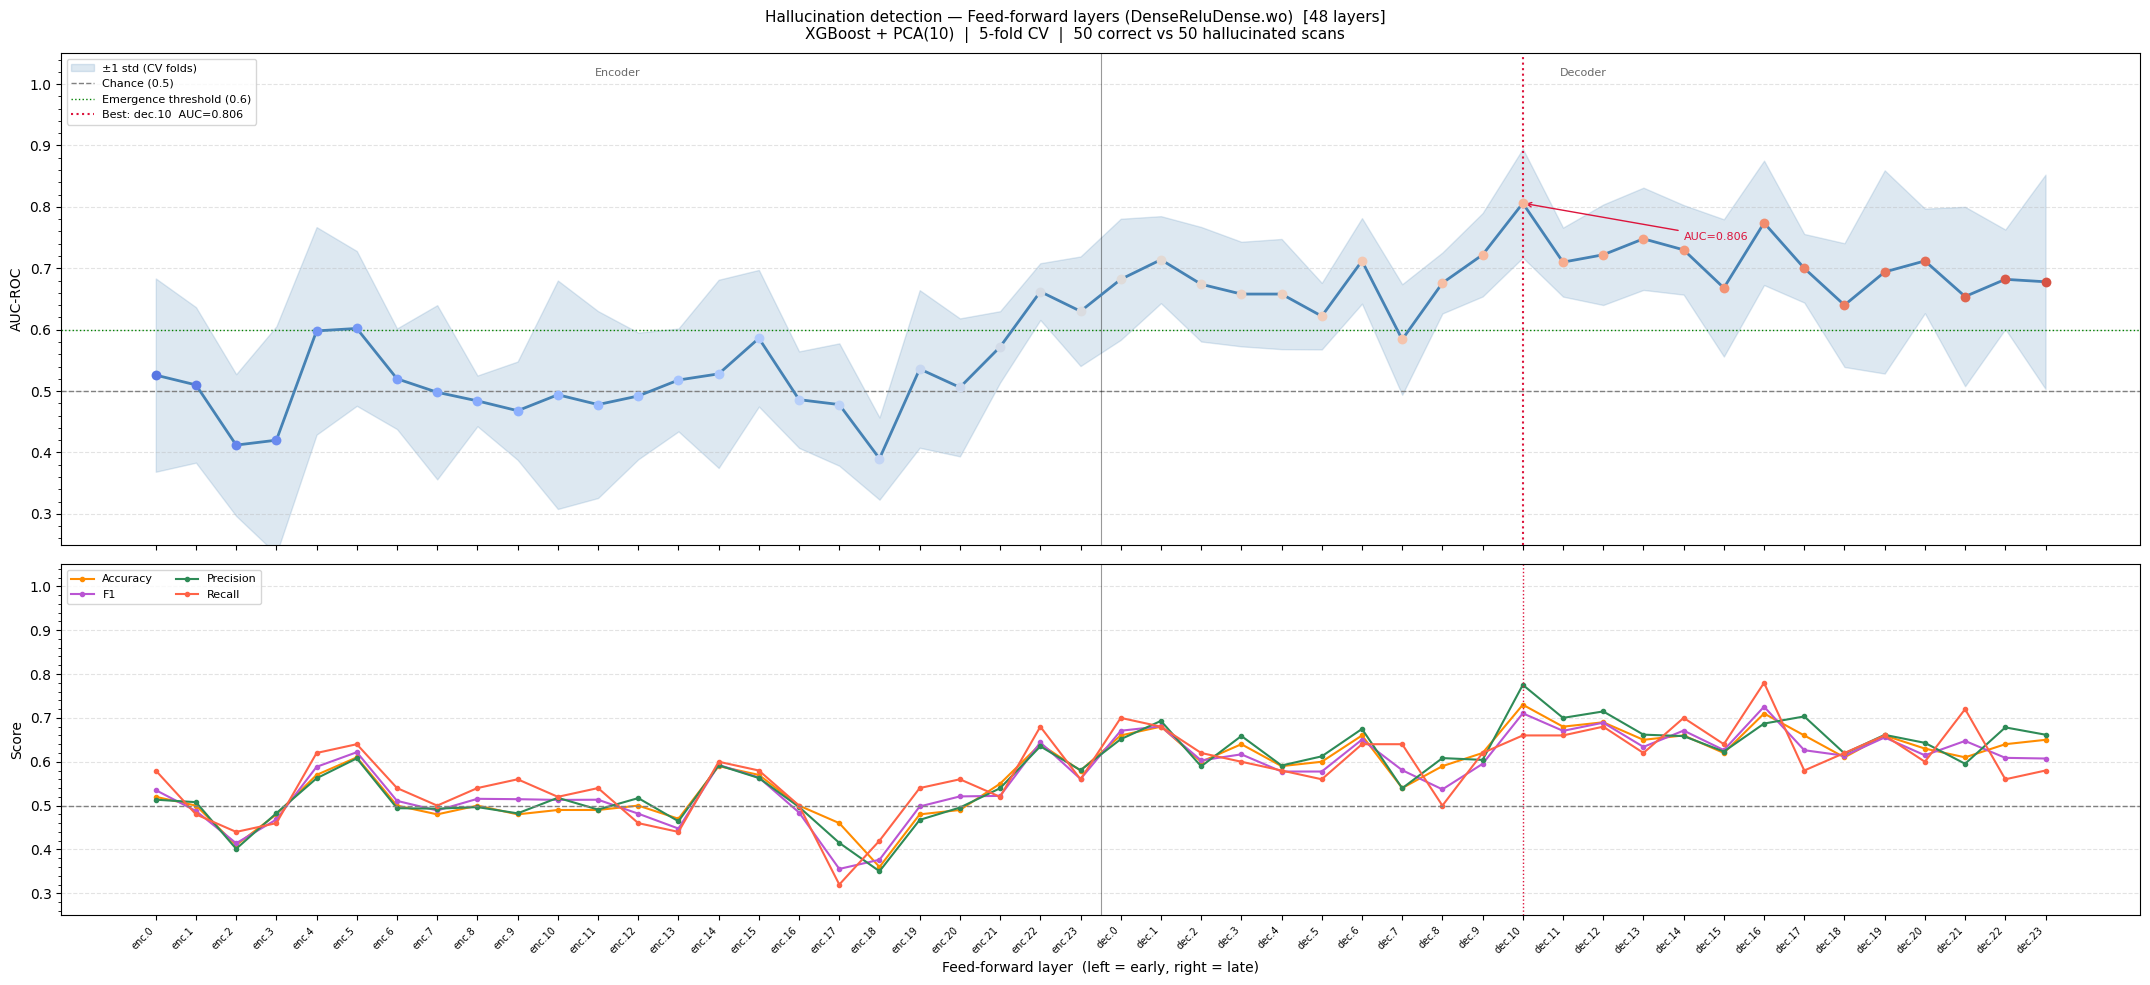

In [7]:
def _find_enc_dec_split(labels):
    """Return the x-index where labels switch from encoder to decoder."""
    for i, lbl in enumerate(labels):
        if lbl.startswith("dec"):
            return i
    return None


def plot_layer_sweep(results, title_prefix, layer_type_label):
    labels = results["labels"]
    n      = len(labels)
    x      = np.arange(n)

    best_idx  = int(np.argmax(results["auc"]))
    split_idx = _find_enc_dec_split(labels)  # may be None

    fig, (ax_auc, ax_rest) = plt.subplots(
        2, 1,
        figsize=(max(14, n * 0.45), 10),
        sharex=True,
        gridspec_kw={"height_ratios": [1.4, 1]},
    )
    fig.suptitle(
        f"{title_prefix}\n"
        f"XGBoost + PCA({K_COMPONENTS})  |  {CV_FOLDS}-fold CV  |  "
        f"{GROUP_SIZE} correct vs {GROUP_SIZE} hallucinated scans",
        fontsize=11,
    )

    # â”€â”€ Top: AUC â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
    ax_auc.fill_between(
        x,
        results["auc"] - results["auc_std"],
        results["auc"] + results["auc_std"],
        alpha=0.18, color="steelblue", label="Â±1 std (CV folds)",
    )
    ax_auc.plot(x, results["auc"], color="steelblue", linewidth=2, zorder=3)
    colors = plt.cm.coolwarm(np.linspace(0.1, 0.9, n))
    for xi, auc, c in zip(x, results["auc"], colors):
        ax_auc.scatter(xi, auc, color=c, s=50, zorder=4, linewidths=0)

    ax_auc.axhline(0.5, color="gray", linestyle="--", linewidth=1, label="Chance (0.5)")
    ax_auc.axhline(
        EMERGENCE_THRESHOLD, color="green", linestyle=":", linewidth=1,
        label=f"Emergence threshold ({EMERGENCE_THRESHOLD})",
    )
    ax_auc.axvline(
        best_idx, color="crimson", linestyle=":", linewidth=1.5,
        label=f"Best: {labels[best_idx]}  AUC={results['auc'][best_idx]:.3f}",
    )
    ax_auc.annotate(
        f"AUC={results['auc'][best_idx]:.3f}",
        xy=(best_idx, results["auc"][best_idx]),
        xytext=(best_idx + max(1, n // 10), results["auc"][best_idx] - 0.06),
        arrowprops=dict(arrowstyle="->", color="crimson"),
        fontsize=8, color="crimson",
    )

    if split_idx is not None:
        for ax in (ax_auc, ax_rest):
            ax.axvline(split_idx - 0.5, color="black", linestyle="-",
                       linewidth=0.8, alpha=0.4)
        ax_auc.text(
            split_idx * 0.5 - 0.5, 0.97, "Encoder",
            transform=ax_auc.get_xaxis_transform(),
            ha="center", va="top", fontsize=8, color="dimgray",
        )
        ax_auc.text(
            (split_idx + n) / 2 - 0.5, 0.97, "Decoder",
            transform=ax_auc.get_xaxis_transform(),
            ha="center", va="top", fontsize=8, color="dimgray",
        )

    ax_auc.set_ylabel("AUC-ROC")
    ax_auc.set_ylim(0.25, 1.05)
    ax_auc.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax_auc.grid(axis="y", linestyle="--", alpha=0.35)
    ax_auc.legend(fontsize=8, loc="upper left")

    # â”€â”€ Bottom: other metrics â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
    metric_cfg = [
        ("accuracy",  "darkorange",  "Accuracy"),
        ("f1",        "mediumorchid", "F1"),
        ("precision", "seagreen",    "Precision"),
        ("recall",    "tomato",      "Recall"),
    ]
    for key, color, display in metric_cfg:
        ax_rest.plot(x, results[key], color=color, linewidth=1.5,
                     marker="o", markersize=3, label=display)

    ax_rest.axhline(0.5, color="gray", linestyle="--", linewidth=1)
    ax_rest.axvline(best_idx, color="crimson", linestyle=":", linewidth=1)

    ax_rest.set_ylabel("Score")
    ax_rest.set_ylim(0.25, 1.05)
    ax_rest.set_xlabel(f"{layer_type_label}  (left = early, right = late)")
    ax_rest.set_xticks(x)
    ax_rest.set_xticklabels(labels, rotation=45, ha="right", fontsize=7)
    ax_rest.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax_rest.grid(axis="y", linestyle="--", alpha=0.35)
    ax_rest.legend(fontsize=8, loc="upper left", ncol=2)

    plt.tight_layout()
    plt.show()


plot_layer_sweep(
    ff_results,
    title_prefix=f"Hallucination detection â€” Feed-forward layers (DenseReluDense.wo)  [{len(ff_layers)} layers]",
    layer_type_label="Feed-forward layer",
)

## Cell 8 â€” Attention layer sweep

Covers encoder self-attention (`enc.*`), decoder self-attention (`dec_sa.*`),
and decoder cross-attention (`dec_ca.*`) in forward-pass order.

In [8]:
print(f"Sweeping {len(attn_layers)} attention layers (SA + CA) ...\n")
attn_results = run_layer_sweep(attn_layers, group_correct, group_hallucinated)

Sweeping 48 attention layers (SA + CA) ...

  [ 0] enc.0         AUC=0.4740  F1=0.4569  Acc=0.4600
  [ 1] enc.1         AUC=0.4600  F1=0.4474  Acc=0.4900
  [ 2] enc.2         AUC=0.4100  F1=0.4506  Acc=0.4300
  [ 3] enc.3         AUC=0.3940  F1=0.4103  Acc=0.4700
  [ 4] enc.4         AUC=0.5240  F1=0.5356  Acc=0.5000
  [ 5] enc.5         AUC=0.4500  F1=0.4091  Acc=0.4400
  [ 6] enc.6         AUC=0.3920  F1=0.4024  Acc=0.3900
  [ 7] enc.7         AUC=0.5000  F1=0.4617  Acc=0.4700
  [ 8] enc.8         AUC=0.3360  F1=0.3955  Acc=0.3900
  [ 9] enc.9         AUC=0.4080  F1=0.4502  Acc=0.4300
  [10] enc.10        AUC=0.5260  F1=0.4952  Acc=0.4900
  [11] enc.11        AUC=0.5260  F1=0.5018  Acc=0.5200
  [12] enc.12        AUC=0.4840  F1=0.4590  Acc=0.4900
  [13] enc.13        AUC=0.4920  F1=0.4719  Acc=0.4600
  [14] enc.14        AUC=0.5920  F1=0.5975  Acc=0.6000
  [15] enc.15        AUC=0.5740  F1=0.5917  Acc=0.5700
  [16] enc.16        AUC=0.4300  F1=0.4831  Acc=0.4400
  [17] enc.17        

E:\Programming\neuralsignal\neuralsignal\.venv\Lib\site-packages\sklearn\decomposition\_pca.py:779: RuntimeWarning: invalid value encountered in divide
  self.explained_variance_ratio_ = self.explained_variance_ / total_var
E:\Programming\neuralsignal\neuralsignal\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
E:\Programming\neuralsignal\neuralsignal\.venv\Lib\site-packages\sklearn\decomposition\_pca.py:779: RuntimeWarning: invalid value encountered in divide
  self.explained_variance_ratio_ = self.explained_variance_ / total_var
E:\Programming\neuralsignal\neuralsignal\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero

  [24] dec_sa.0      AUC=0.5000  F1=0.0000  Acc=0.5000
  [25] dec_sa.1      AUC=0.5000  F1=0.4364  Acc=0.4900
  [26] dec_sa.2      AUC=0.6080  F1=0.5934  Acc=0.6000
  [27] dec_sa.3      AUC=0.5920  F1=0.5051  Acc=0.5400
  [28] dec_sa.4      AUC=0.6800  F1=0.5766  Acc=0.6000
  [29] dec_sa.5      AUC=0.6800  F1=0.6730  Acc=0.6900
  [30] dec_sa.6      AUC=0.6960  F1=0.6232  Acc=0.6100
  [31] dec_sa.7      AUC=0.6220  F1=0.6261  Acc=0.6100
  [32] dec_sa.8      AUC=0.5680  F1=0.5627  Acc=0.5400
  [33] dec_sa.9      AUC=0.6340  F1=0.6073  Acc=0.6100
  [34] dec_sa.10     AUC=0.6440  F1=0.5666  Acc=0.5800
  [35] dec_sa.11     AUC=0.6820  F1=0.6728  Acc=0.6500
  [36] dec_sa.12     AUC=0.6160  F1=0.5495  Acc=0.5600
  [37] dec_sa.13     AUC=0.6920  F1=0.6567  Acc=0.6800
  [38] dec_sa.14     AUC=0.7780  F1=0.7078  Acc=0.6900
  [39] dec_sa.15     AUC=0.7480  F1=0.7055  Acc=0.7000
  [40] dec_sa.16     AUC=0.6680  F1=0.6078  Acc=0.6200
  [41] dec_sa.17     AUC=0.7840  F1=0.6602  Acc=0.6900
  [42] dec

## Cell 9 â€” Attention layer plots

Same two-panel layout as Cell 7.
Vertical dividers mark the encoderâ†’decoder and SAâ†’CA transitions.

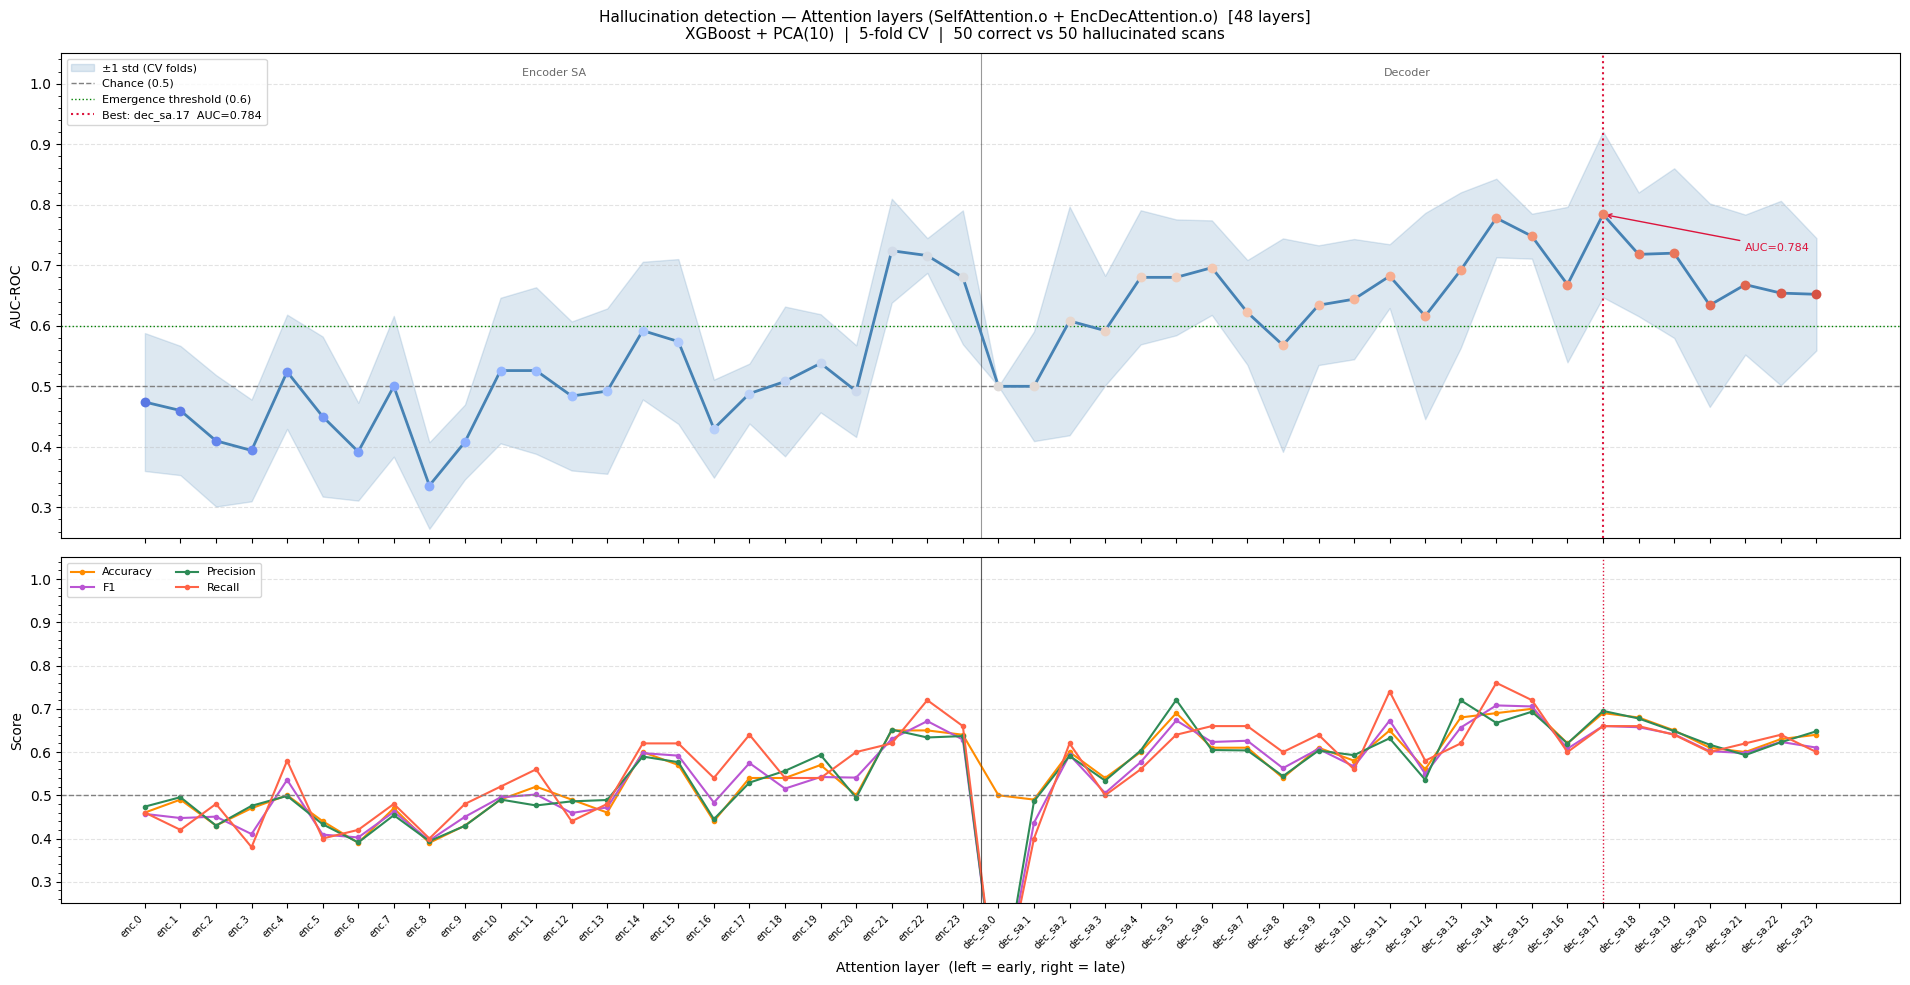

In [9]:
def _find_attn_splits(labels):
    """Return (enc_dec_split, sa_ca_split) x-indices."""
    enc_dec = next((i for i, l in enumerate(labels) if l.startswith("dec")), None)
    sa_ca   = next((i for i, l in enumerate(labels) if l.startswith("dec_ca")), None)
    return enc_dec, sa_ca


def plot_attn_sweep(results):
    labels = results["labels"]
    n      = len(labels)
    x      = np.arange(n)

    best_idx           = int(np.argmax(results["auc"]))
    enc_dec, sa_ca     = _find_attn_splits(labels)

    fig, (ax_auc, ax_rest) = plt.subplots(
        2, 1,
        figsize=(max(16, n * 0.4), 10),
        sharex=True,
        gridspec_kw={"height_ratios": [1.4, 1]},
    )
    fig.suptitle(
        f"Hallucination detection â€” Attention layers (SelfAttention.o + EncDecAttention.o)  [{n} layers]\n"
        f"XGBoost + PCA({K_COMPONENTS})  |  {CV_FOLDS}-fold CV  |  "
        f"{GROUP_SIZE} correct vs {GROUP_SIZE} hallucinated scans",
        fontsize=11,
    )

    # â”€â”€ Top: AUC â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
    ax_auc.fill_between(
        x,
        results["auc"] - results["auc_std"],
        results["auc"] + results["auc_std"],
        alpha=0.18, color="steelblue", label="Â±1 std (CV folds)",
    )
    ax_auc.plot(x, results["auc"], color="steelblue", linewidth=2, zorder=3)
    colors = plt.cm.coolwarm(np.linspace(0.1, 0.9, n))
    for xi, auc, c in zip(x, results["auc"], colors):
        ax_auc.scatter(xi, auc, color=c, s=50, zorder=4, linewidths=0)

    ax_auc.axhline(0.5, color="gray", linestyle="--", linewidth=1, label="Chance (0.5)")
    ax_auc.axhline(
        EMERGENCE_THRESHOLD, color="green", linestyle=":", linewidth=1,
        label=f"Emergence threshold ({EMERGENCE_THRESHOLD})",
    )
    ax_auc.axvline(
        best_idx, color="crimson", linestyle=":", linewidth=1.5,
        label=f"Best: {labels[best_idx]}  AUC={results['auc'][best_idx]:.3f}",
    )
    ax_auc.annotate(
        f"AUC={results['auc'][best_idx]:.3f}",
        xy=(best_idx, results["auc"][best_idx]),
        xytext=(best_idx + max(1, n // 10), results["auc"][best_idx] - 0.06),
        arrowprops=dict(arrowstyle="->", color="crimson"),
        fontsize=8, color="crimson",
    )

    # Section dividers + labels
    section_breaks = [
        (enc_dec, "Encoder SA", "Decoder"),
        (sa_ca,   None,         "Decoder CA"),
    ]
    section_starts = [0]
    section_names  = ["Encoder SA"]
    for split, _, label_right in section_breaks:
        if split is not None:
            for ax in (ax_auc, ax_rest):
                ax.axvline(split - 0.5, color="black", linestyle="-",
                           linewidth=0.8, alpha=0.4)
            section_starts.append(split)
            section_names.append(label_right)

    section_ends = section_starts[1:] + [n]
    for start, end, sname in zip(section_starts, section_ends, section_names):
        mid_x = (start + end) / 2 - 0.5
        ax_auc.text(
            mid_x, 0.97, sname,
            transform=ax_auc.get_xaxis_transform(),
            ha="center", va="top", fontsize=8, color="dimgray",
        )

    ax_auc.set_ylabel("AUC-ROC")
    ax_auc.set_ylim(0.25, 1.05)
    ax_auc.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax_auc.grid(axis="y", linestyle="--", alpha=0.35)
    ax_auc.legend(fontsize=8, loc="upper left")

    # â”€â”€ Bottom: other metrics â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
    metric_cfg = [
        ("accuracy",  "darkorange",  "Accuracy"),
        ("f1",        "mediumorchid", "F1"),
        ("precision", "seagreen",    "Precision"),
        ("recall",    "tomato",      "Recall"),
    ]
    for key, color, display in metric_cfg:
        ax_rest.plot(x, results[key], color=color, linewidth=1.5,
                     marker="o", markersize=3, label=display)

    ax_rest.axhline(0.5, color="gray", linestyle="--", linewidth=1)
    ax_rest.axvline(best_idx, color="crimson", linestyle=":", linewidth=1)
    for split, _, _ in section_breaks:
        if split is not None:
            ax_rest.axvline(split - 0.5, color="black", linestyle="-",
                            linewidth=0.8, alpha=0.4)

    ax_rest.set_ylabel("Score")
    ax_rest.set_ylim(0.25, 1.05)
    ax_rest.set_xlabel("Attention layer  (left = early, right = late)")
    ax_rest.set_xticks(x)
    ax_rest.set_xticklabels(labels, rotation=45, ha="right", fontsize=7)
    ax_rest.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax_rest.grid(axis="y", linestyle="--", alpha=0.35)
    ax_rest.legend(fontsize=8, loc="upper left", ncol=2)

    plt.tight_layout()
    plt.show()


plot_attn_sweep(attn_results)

## Cell 10 â€” Summary comparison

Side-by-side comparison of the best AUC per layer family and a printed summary
of peak performance and signal emergence for each.

â”€â”€ Feed-forward  (DenseReluDense.wo) â”€â”€
  Layers      : 48
  Peak AUC    : 0.8060  @ layer [34] dec.10
  Emergence   : layer [5] enc.5  (AUC=0.6020)
  Peak F1     : 0.7256  @ layer [40] dec.16

â”€â”€ Attention     (SA + CA) â”€â”€
  Layers      : 48
  Peak AUC    : 0.7840  @ layer [41] dec_sa.17
  Emergence   : layer [21] enc.21  (AUC=0.7240)
  Peak F1     : 0.7078  @ layer [38] dec_sa.14



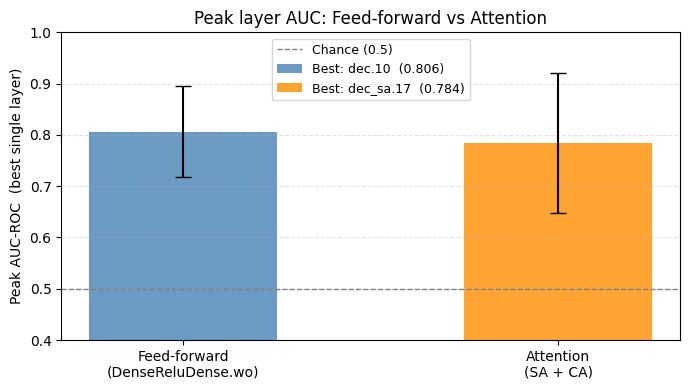

In [10]:
def sweep_summary(results, name):
    labels    = results["labels"]
    aucs      = results["auc"]
    best_idx  = int(np.argmax(aucs))
    emerge    = next((i for i, a in enumerate(aucs) if a >= EMERGENCE_THRESHOLD), None)

    print(f"â”€â”€ {name} â”€â”€")
    print(f"  Layers      : {len(labels)}")
    print(f"  Peak AUC    : {aucs[best_idx]:.4f}  @ layer [{best_idx}] {labels[best_idx]}")
    if emerge is not None:
        print(f"  Emergence   : layer [{emerge}] {labels[emerge]}  (AUC={aucs[emerge]:.4f})")
    else:
        print(f"  Emergence   : not reached (threshold={EMERGENCE_THRESHOLD})")
    print(f"  Peak F1     : {results['f1'].max():.4f}  @ layer [{int(np.argmax(results['f1']))}] {labels[int(np.argmax(results['f1']))]}")
    print()

sweep_summary(ff_results,   "Feed-forward  (DenseReluDense.wo)")
sweep_summary(attn_results, "Attention     (SA + CA)")

# â”€â”€ Bar chart: peak AUC per layer type â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
fig, ax = plt.subplots(figsize=(7, 4))

sweeps = [
    ("Feed-forward\n(DenseReluDense.wo)", ff_results),
    ("Attention\n(SA + CA)",              attn_results),
]

bar_colors = ["steelblue", "darkorange"]
for xi, ((sweep_name, res), color) in enumerate(zip(sweeps, bar_colors)):
    best = int(np.argmax(res["auc"]))
    ax.bar(
        xi, res["auc"][best],
        color=color, alpha=0.8, width=0.5,
        label=f"Best: {res['labels'][best]}  ({res['auc'][best]:.3f})",
    )
    ax.errorbar(
        xi, res["auc"][best], yerr=res["auc_std"][best],
        fmt="none", color="black", capsize=6, linewidth=1.5,
    )

ax.axhline(0.5, color="gray", linestyle="--", linewidth=1, label="Chance (0.5)")
ax.set_xticks([0, 1])
ax.set_xticklabels([s for s, _ in sweeps], fontsize=10)
ax.set_ylabel("Peak AUC-ROC  (best single layer)")
ax.set_ylim(0.4, 1.0)
ax.set_title("Peak layer AUC: Feed-forward vs Attention", fontsize=12)
ax.legend(fontsize=9)
ax.grid(axis="y", linestyle="--", alpha=0.35)
plt.tight_layout()
plt.show()

## Cell 11 — Statistical significance of per-layer AUC

Instead of a fixed threshold, we use a **one-sample t-test** per layer
(H₀: mean AUC = 0.5, H₁: mean AUC > 0.5) across the CV fold scores,
then apply **Benjamini-Hochberg FDR correction** for multiple comparisons.

Bonferroni would be too conservative here because adjacent layers are correlated
(activations propagate deterministically through the network), so BH controls
the false discovery rate instead.

The **emergence layer** becomes the first layer where H₀ is rejected after correction.

In [12]:
from scipy.stats import ttest_1samp
from statsmodels.stats.multitest import multipletests

print('Stat-sig imports OK')

Stat-sig imports OK


## Cell 12 — Sweep wrapper that retains per-fold AUC arrays

The t-test needs the raw fold scores, not just the mean.
This wrapper is identical to `run_layer_sweep` but also stores
`auc_folds` (one array of length `CV_FOLDS` per layer).
Existing cell results are untouched.

In [13]:
def run_layer_sweep_with_folds(layers, group_correct, group_hallucinated):
    """Identical to run_layer_sweep but also stores raw per-fold AUC arrays."""
    cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

    labels       = []
    metric_means = {m: [] for m in SCORING}
    metric_stds  = {m: [] for m in SCORING}
    auc_folds    = []

    for i, (lid, name, label) in enumerate(layers):
        vecs_c, _ = build_matrix(group_correct,      lid)
        vecs_h, _ = build_matrix(group_hallucinated, lid, expected_dim=vecs_c.shape[1])

        X = np.vstack([vecs_c.numpy(), vecs_h.numpy()])
        y = np.array([0] * len(vecs_c) + [1] * len(vecs_h))

        k = min(K_COMPONENTS, X.shape[1], X.shape[0] - 1)
        pipe = Pipeline([
            ('pca', PCA(n_components=k, random_state=RANDOM_STATE)),
            ('clf', XGBClassifier(
                n_estimators=100, verbosity=0,
                random_state=RANDOM_STATE, eval_metric='logloss',
            )),
        ])

        results = cross_validate(
            pipe, X, y, cv=cv,
            scoring=SCORING,
            return_train_score=False,
        )

        auc_folds.append(results['test_roc_auc'])
        labels.append(label)
        for m in SCORING:
            metric_means[m].append(results[f'test_{m}'].mean())
            metric_stds[m].append(results[f'test_{m}'].std())

        auc  = metric_means['roc_auc'][-1]
        f1   = metric_means['f1'][-1]
        acc  = metric_means['accuracy'][-1]
        print(f'  [{i:>2}] {label:<12}  AUC={auc:.4f}  F1={f1:.4f}  Acc={acc:.4f}')

    out = {'labels': labels, 'auc_folds': auc_folds}
    for m in SCORING:
        out[m]          = np.array(metric_means[m])
        out[f'{m}_std'] = np.array(metric_stds[m])
    out['auc']     = out.pop('roc_auc')
    out['auc_std'] = out.pop('roc_auc_std')
    return out


def compute_significance(results, alpha=0.05):
    """One-sample t-test (H0: AUC=0.5) per layer + BH FDR correction.

    Returns dict with p_raw, p_corrected, reject, t_stats.
    """
    pairs = [ttest_1samp(folds, popmean=0.5, alternative='greater')
             for folds in results['auc_folds']]
    t_stats = np.array([t for t, _ in pairs])
    p_raw   = np.array([p for _, p in pairs])

    reject, p_corrected, _, _ = multipletests(p_raw, alpha=alpha, method='fdr_bh')

    return {'p_raw': p_raw, 'p_corrected': p_corrected,
            'reject': reject, 't_stats': t_stats}


print('Helpers defined')

Helpers defined


## Cell 13 — Re-run sweeps retaining fold scores

Results are stored in new variables so existing cell outputs are untouched.

In [14]:
print('Re-running feed-forward sweep ...\n')
ff_results_sig = run_layer_sweep_with_folds(ff_layers, group_correct, group_hallucinated)

print('\nRe-running attention sweep ...\n')
attn_results_sig = run_layer_sweep_with_folds(attn_layers, group_correct, group_hallucinated)

Re-running feed-forward sweep ...

  [ 0] enc.0         AUC=0.5260  F1=0.5353  Acc=0.5200
  [ 1] enc.1         AUC=0.5100  F1=0.4877  Acc=0.5000
  [ 2] enc.2         AUC=0.4120  F1=0.4141  Acc=0.4100
  [ 3] enc.3         AUC=0.4200  F1=0.4683  Acc=0.4800
  [ 4] enc.4         AUC=0.5980  F1=0.5884  Acc=0.5700
  [ 5] enc.5         AUC=0.6020  F1=0.6217  Acc=0.6100
  [ 6] enc.6         AUC=0.5200  F1=0.5108  Acc=0.5000
  [ 7] enc.7         AUC=0.4980  F1=0.4888  Acc=0.4800
  [ 8] enc.8         AUC=0.4840  F1=0.5155  Acc=0.5000
  [ 9] enc.9         AUC=0.4680  F1=0.5146  Acc=0.4800
  [10] enc.10        AUC=0.4940  F1=0.5130  Acc=0.4900
  [11] enc.11        AUC=0.4780  F1=0.5134  Acc=0.4900
  [12] enc.12        AUC=0.4920  F1=0.4816  Acc=0.5000
  [13] enc.13        AUC=0.5180  F1=0.4477  Acc=0.4700
  [14] enc.14        AUC=0.5280  F1=0.5928  Acc=0.5900
  [15] enc.15        AUC=0.5860  F1=0.5640  Acc=0.5700
  [16] enc.16        AUC=0.4860  F1=0.4842  Acc=0.5000
  [17] enc.17        AUC=0.478

E:\Programming\neuralsignal\neuralsignal\.venv\Lib\site-packages\sklearn\decomposition\_pca.py:779: RuntimeWarning: invalid value encountered in divide
  self.explained_variance_ratio_ = self.explained_variance_ / total_var
E:\Programming\neuralsignal\neuralsignal\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
E:\Programming\neuralsignal\neuralsignal\.venv\Lib\site-packages\sklearn\decomposition\_pca.py:779: RuntimeWarning: invalid value encountered in divide
  self.explained_variance_ratio_ = self.explained_variance_ / total_var
E:\Programming\neuralsignal\neuralsignal\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero

  [24] dec_sa.0      AUC=0.5000  F1=0.0000  Acc=0.5000
  [25] dec_sa.1      AUC=0.5000  F1=0.4364  Acc=0.4900
  [26] dec_sa.2      AUC=0.6080  F1=0.5934  Acc=0.6000
  [27] dec_sa.3      AUC=0.5920  F1=0.5051  Acc=0.5400
  [28] dec_sa.4      AUC=0.6800  F1=0.5766  Acc=0.6000
  [29] dec_sa.5      AUC=0.6800  F1=0.6730  Acc=0.6900
  [30] dec_sa.6      AUC=0.6960  F1=0.6232  Acc=0.6100
  [31] dec_sa.7      AUC=0.6220  F1=0.6261  Acc=0.6100
  [32] dec_sa.8      AUC=0.5680  F1=0.5627  Acc=0.5400
  [33] dec_sa.9      AUC=0.6340  F1=0.6073  Acc=0.6100
  [34] dec_sa.10     AUC=0.6440  F1=0.5666  Acc=0.5800
  [35] dec_sa.11     AUC=0.6820  F1=0.6728  Acc=0.6500
  [36] dec_sa.12     AUC=0.6160  F1=0.5495  Acc=0.5600
  [37] dec_sa.13     AUC=0.6920  F1=0.6567  Acc=0.6800
  [38] dec_sa.14     AUC=0.7780  F1=0.7078  Acc=0.6900
  [39] dec_sa.15     AUC=0.7480  F1=0.7055  Acc=0.7000
  [40] dec_sa.16     AUC=0.6680  F1=0.6078  Acc=0.6200
  [41] dec_sa.17     AUC=0.7840  F1=0.6602  Acc=0.6900
  [42] dec

## Cell 14 — Significance plots

Three panels per layer family:
- **Top**: mean AUC per layer — stars (★) mark layers significant after BH correction
- **Middle**: raw and BH-corrected p-values on a log scale with the α line
- **Bottom**: t-statistics as a bar chart (green = significant)

The green vertical line marks the **first statistically significant layer** — the
earliest point where the signal is distinguishable from chance.

E:\Programming\neuralsignal\neuralsignal\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


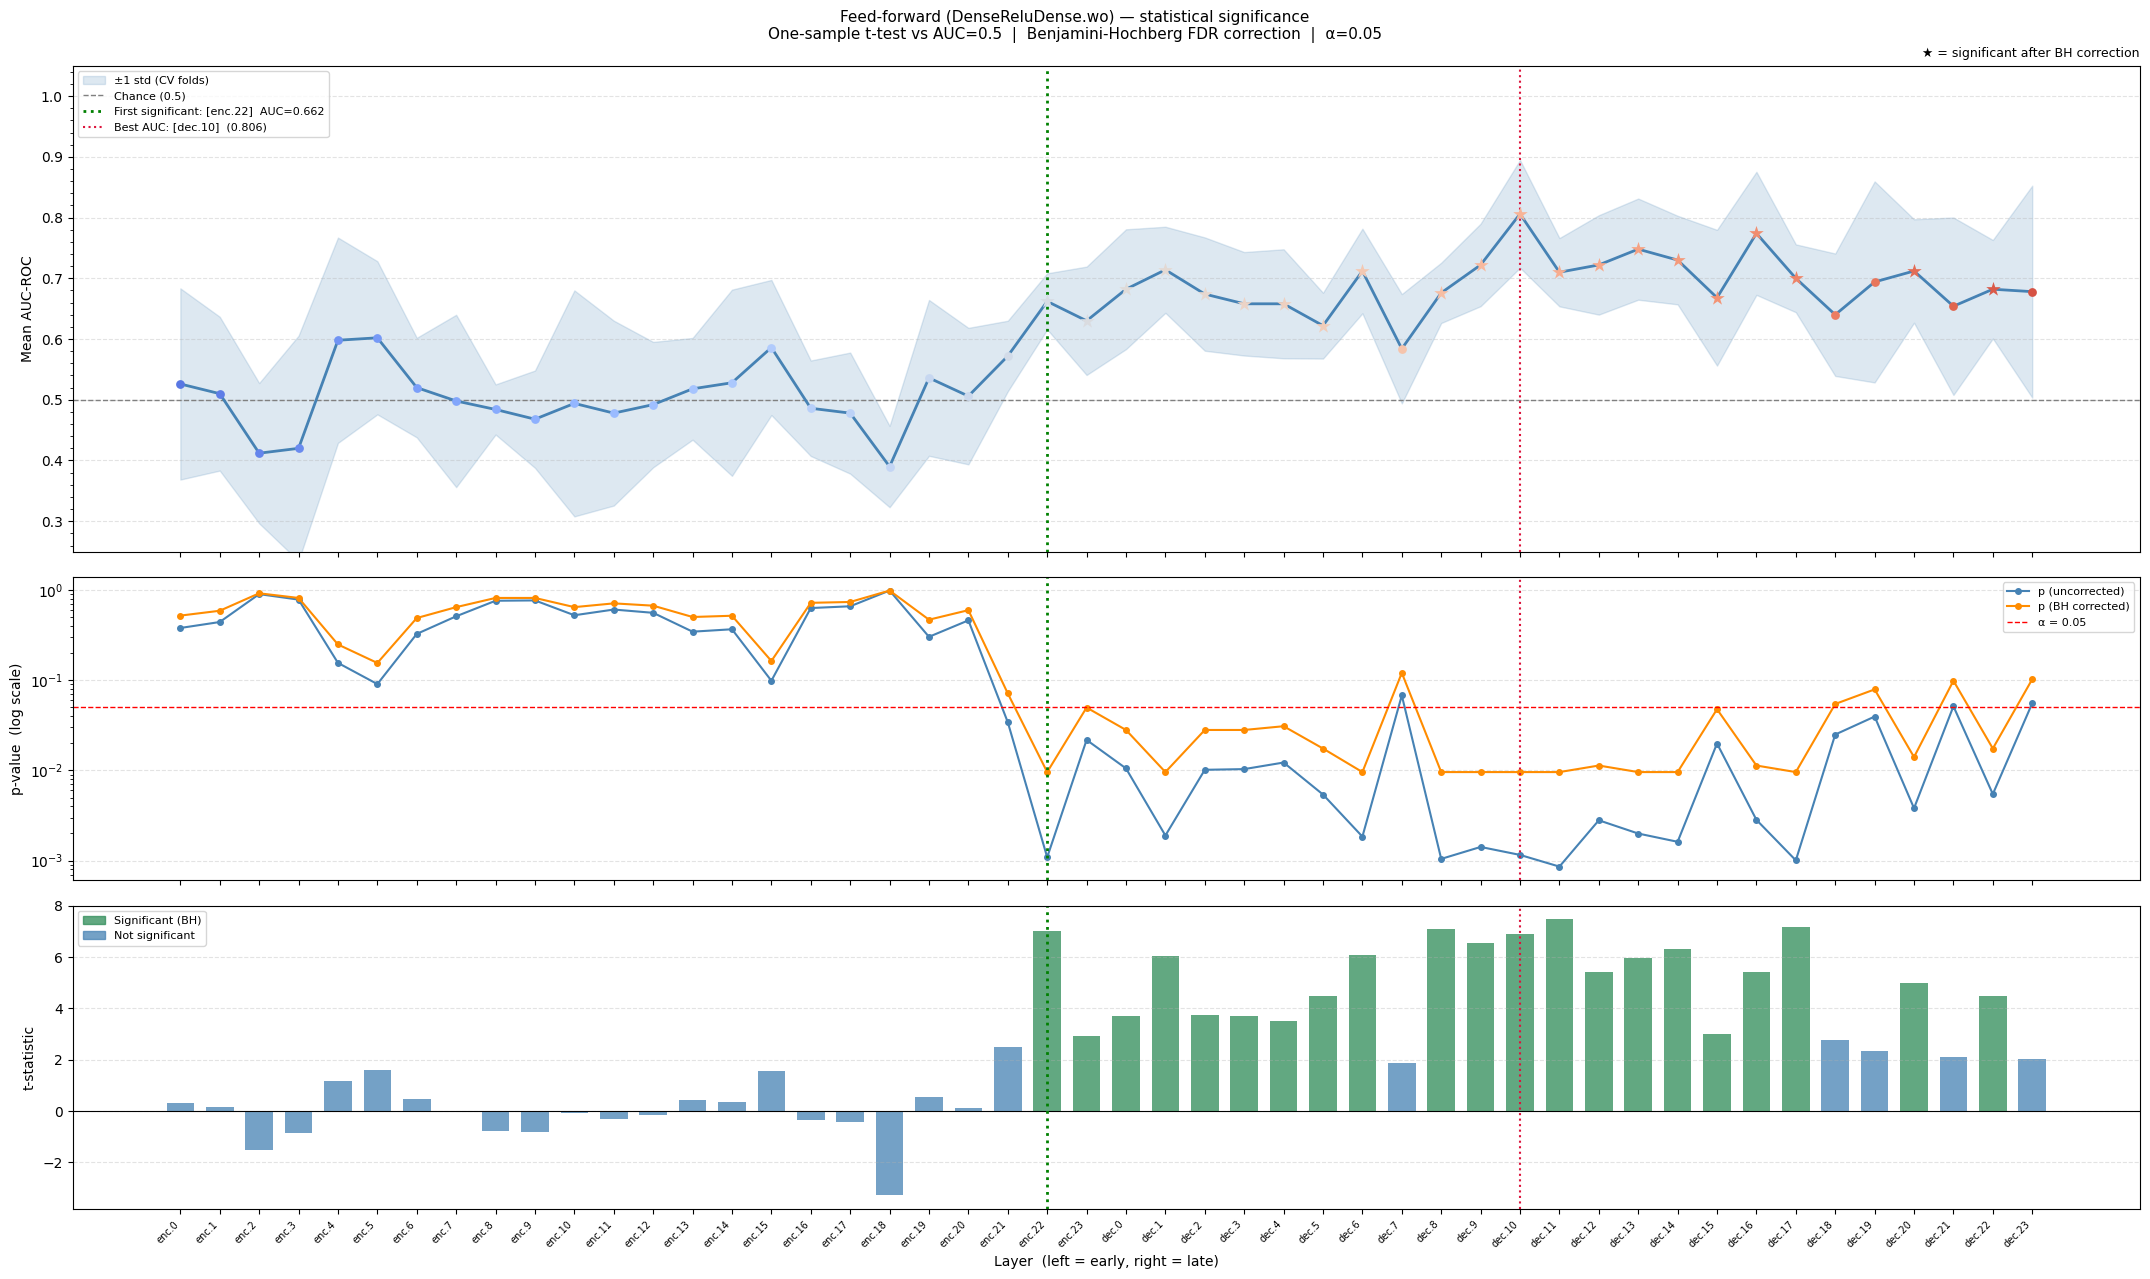


── Feed-forward (DenseReluDense.wo) ──
  First significant layer : [22] enc.22
    AUC     = 0.6620
    p (raw) = 1.0900e-03
    p (BH)  = 9.5750e-03
    t-stat  = 7.0104
  Significant layers : 21 / 48


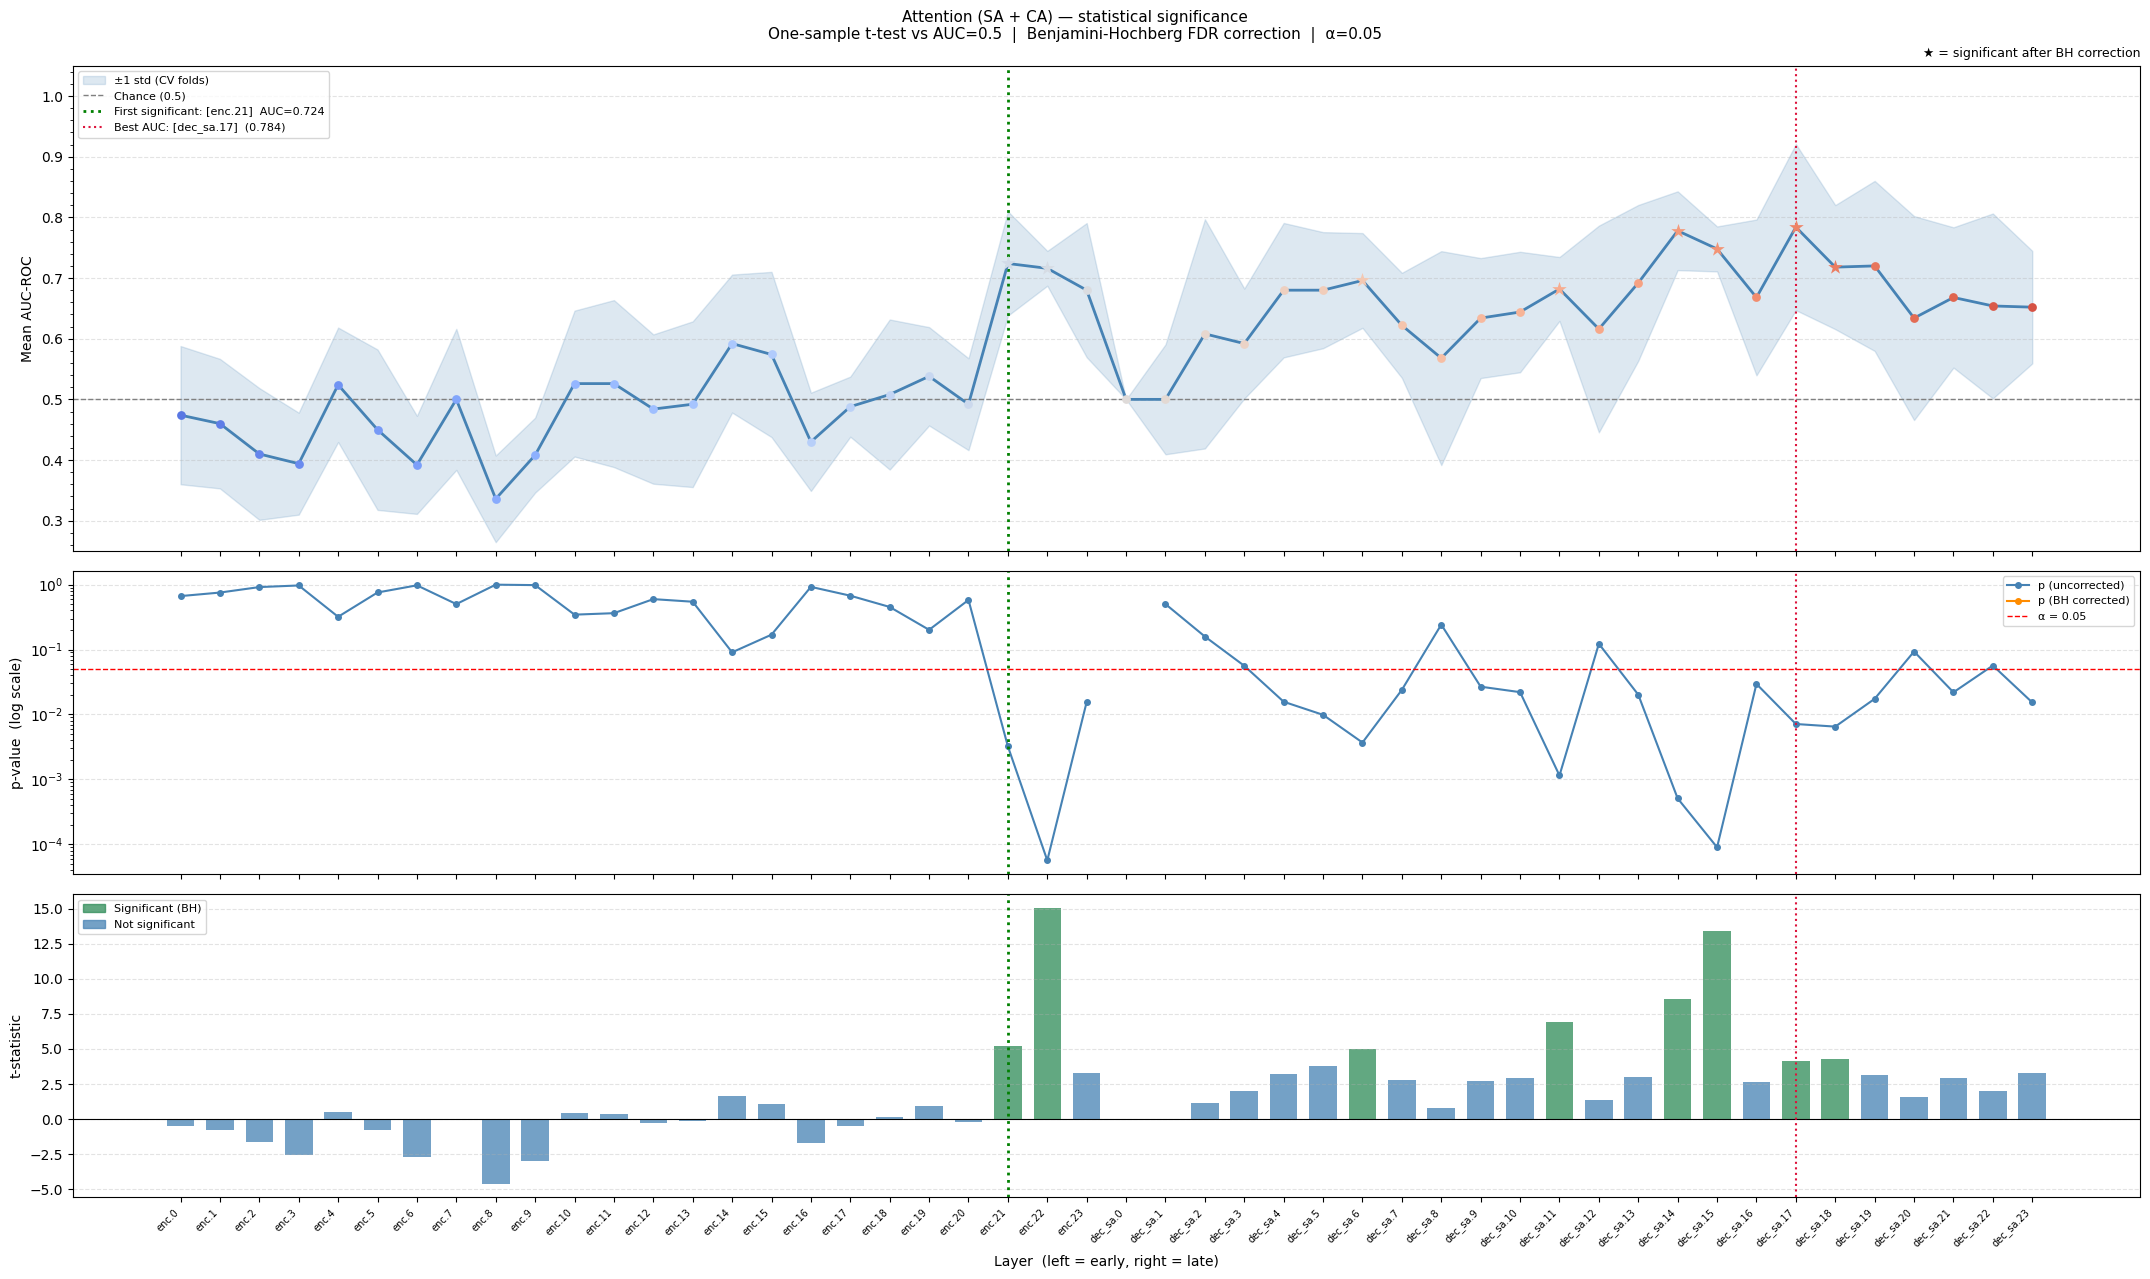


── Attention (SA + CA) ──
  First significant layer : [21] enc.21
    AUC     = 0.7240
    p (raw) = 3.2280e-03
    p (BH)  = nan
    t-stat  = 5.2135
  Significant layers : 8 / 48


In [15]:
from matplotlib.patches import Patch


def plot_significance(results, sig, title_prefix, alpha=0.05):
    labels      = results['labels']
    n           = len(labels)
    x           = np.arange(n)
    reject      = sig['reject']
    p_raw       = sig['p_raw']
    p_corrected = sig['p_corrected']
    t_stats     = sig['t_stats']

    first_sig = next((i for i, r in enumerate(reject) if r), None)
    best_idx  = int(np.argmax(results['auc']))

    fig, (ax_auc, ax_p, ax_t) = plt.subplots(
        3, 1,
        figsize=(max(14, n * 0.45), 13),
        sharex=True,
        gridspec_kw={'height_ratios': [1.6, 1, 1]},
    )
    fig.suptitle(
        f'{title_prefix} — statistical significance\n'
        f'One-sample t-test vs AUC=0.5  |  Benjamini-Hochberg FDR correction  |  α={alpha}',
        fontsize=11,
    )

    # ── Top: AUC with significance markers ────────────────────────────────────
    ax_auc.fill_between(
        x,
        results['auc'] - results['auc_std'],
        results['auc'] + results['auc_std'],
        alpha=0.18, color='steelblue', label='±1 std (CV folds)',
    )
    ax_auc.plot(x, results['auc'], color='steelblue', linewidth=2, zorder=3)
    colors = plt.cm.coolwarm(np.linspace(0.1, 0.9, n))
    for xi, auc, c, is_sig in zip(x, results['auc'], colors, reject):
        ax_auc.scatter(xi, auc, color=c, s=120 if is_sig else 40,
                       zorder=4, linewidths=0, marker='*' if is_sig else 'o')

    ax_auc.axhline(0.5, color='gray', linestyle='--', linewidth=1, label='Chance (0.5)')
    if first_sig is not None:
        ax_auc.axvline(
            first_sig, color='green', linestyle=':', linewidth=2,
            label=f'First significant: [{labels[first_sig]}]  AUC={results["auc"][first_sig]:.3f}',
        )
    ax_auc.axvline(
        best_idx, color='crimson', linestyle=':', linewidth=1.5,
        label=f'Best AUC: [{labels[best_idx]}]  ({results["auc"][best_idx]:.3f})',
    )
    ax_auc.set_ylabel('Mean AUC-ROC')
    ax_auc.set_ylim(0.25, 1.05)
    ax_auc.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax_auc.grid(axis='y', linestyle='--', alpha=0.35)
    ax_auc.legend(fontsize=8, loc='upper left')
    ax_auc.set_title('★ = significant after BH correction', fontsize=9, loc='right')

    # ── Middle: p-values (log scale) ──────────────────────────────────────────
    ax_p.semilogy(x, p_raw,       color='steelblue',  linewidth=1.5,
                  marker='o', markersize=4, label='p (uncorrected)')
    ax_p.semilogy(x, p_corrected, color='darkorange', linewidth=1.5,
                  marker='o', markersize=4, label='p (BH corrected)')
    ax_p.axhline(alpha, color='red', linestyle='--', linewidth=1, label=f'α = {alpha}')
    if first_sig is not None:
        ax_p.axvline(first_sig, color='green',  linestyle=':', linewidth=2)
    ax_p.axvline(best_idx,  color='crimson', linestyle=':', linewidth=1.5)
    ax_p.set_ylabel('p-value  (log scale)')
    ax_p.grid(axis='y', linestyle='--', alpha=0.35)
    ax_p.legend(fontsize=8, loc='upper right')

    # ── Bottom: t-statistics ──────────────────────────────────────────────────
    bar_colors = ['seagreen' if r else 'steelblue' for r in reject]
    ax_t.bar(x, t_stats, color=bar_colors, alpha=0.75, width=0.7)
    ax_t.axhline(0, color='black', linewidth=0.8)
    if first_sig is not None:
        ax_t.axvline(first_sig, color='green', linestyle=':', linewidth=2)
    ax_t.axvline(best_idx, color='crimson', linestyle=':', linewidth=1.5)
    ax_t.set_ylabel('t-statistic')
    ax_t.set_xlabel('Layer  (left = early, right = late)')
    ax_t.set_xticks(x)
    ax_t.set_xticklabels(labels, rotation=45, ha='right', fontsize=7)
    ax_t.grid(axis='y', linestyle='--', alpha=0.35)
    ax_t.legend(
        handles=[
            Patch(color='seagreen',  alpha=0.75, label='Significant (BH)'),
            Patch(color='steelblue', alpha=0.75, label='Not significant'),
        ],
        fontsize=8, loc='upper left',
    )

    plt.tight_layout()
    plt.show()

    # Printed summary
    print(f'\n── {title_prefix} ──')
    if first_sig is not None:
        print(f'  First significant layer : [{first_sig}] {labels[first_sig]}')
        print(f'    AUC     = {results["auc"][first_sig]:.4f}')
        print(f'    p (raw) = {p_raw[first_sig]:.4e}')
        print(f'    p (BH)  = {p_corrected[first_sig]:.4e}')
        print(f'    t-stat  = {t_stats[first_sig]:.4f}')
    else:
        print('  No layer reached significance after BH correction.')
    print(f'  Significant layers : {int(reject.sum())} / {n}')


ALPHA = 0.05
ff_sig   = compute_significance(ff_results_sig,   alpha=ALPHA)
attn_sig = compute_significance(attn_results_sig, alpha=ALPHA)

plot_significance(ff_results_sig,   ff_sig,   'Feed-forward (DenseReluDense.wo)', alpha=ALPHA)
plot_significance(attn_results_sig, attn_sig, 'Attention (SA + CA)',              alpha=ALPHA)

## Cell 15 — Cumulative layer sweep

For each step N we concatenate the activation vectors from layers **0 through N**
into a single feature vector and train the classifier on that.

This answers a different question from the per-layer sweep:
- **Per-layer**: which single layer is most informative?
- **Cumulative**: how much does each additional layer contribute on top of everything before it?

The curve will show where AUC starts climbing (signal emergence) and where it
plateaus (point of diminishing returns — adding more layers stops helping).

PCA(`K_COMPONENTS`) is applied to the full concatenated vector at each step,
keeping the classifier input dimension fixed across all steps for a fair comparison.

In [16]:
def build_cumulative_matrix(scans, layers_so_far):
    """For each scan concatenate last-token vectors from all layers in layers_so_far.

    Skips scans where any layer extraction fails.
    Returns (X array of shape [n_scans, sum_of_hidden_dims], n_skipped).
    """
    vecs, skipped = [], 0
    for scan in scans:
        try:
            parts = [extract_vector(scan, lid).numpy() for lid, _, _ in layers_so_far]
            vecs.append(np.concatenate(parts))
        except Exception:
            skipped += 1
    return np.array(vecs), skipped


def run_cumulative_sweep(layers, group_correct, group_hallucinated, verbose=True):
    """Cumulative per-layer sweep.

    At step N uses layers[0..N] concatenated as features.
    Returns the same dict structure as run_layer_sweep_with_folds.
    """
    cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

    labels       = []
    metric_means = {m: [] for m in SCORING}
    metric_stds  = {m: [] for m in SCORING}
    auc_folds    = []

    for n in range(len(layers)):
        layers_so_far = layers[:n + 1]
        label = layers[n][2]   # label of the last added layer

        X_c, _ = build_cumulative_matrix(group_correct,      layers_so_far)
        X_h, _ = build_cumulative_matrix(group_hallucinated, layers_so_far)

        X = np.vstack([X_c, X_h])
        y = np.array([0] * len(X_c) + [1] * len(X_h))

        k = min(K_COMPONENTS, X.shape[1], X.shape[0] - 1)
        pipe = Pipeline([
            ('pca', PCA(n_components=k, random_state=RANDOM_STATE)),
            ('clf', XGBClassifier(
                n_estimators=100, verbosity=0,
                random_state=RANDOM_STATE, eval_metric='logloss',
            )),
        ])

        results = cross_validate(
            pipe, X, y, cv=cv,
            scoring=SCORING,
            return_train_score=False,
        )

        auc_folds.append(results['test_roc_auc'])
        labels.append(label)
        for m in SCORING:
            metric_means[m].append(results[f'test_{m}'].mean())
            metric_stds[m].append(results[f'test_{m}'].std())

        if verbose:
            auc = metric_means['roc_auc'][-1]
            f1  = metric_means['f1'][-1]
            acc = metric_means['accuracy'][-1]
            print(f'  [{n:>2}] up to {label:<12}  AUC={auc:.4f}  F1={f1:.4f}  Acc={acc:.4f}')

    out = {'labels': labels, 'auc_folds': auc_folds}
    for m in SCORING:
        out[m]          = np.array(metric_means[m])
        out[f'{m}_std'] = np.array(metric_stds[m])
    out['auc']     = out.pop('roc_auc')
    out['auc_std'] = out.pop('roc_auc_std')
    return out


print('Cumulative sweep helper defined')

Cumulative sweep helper defined


## Cell 16 — Run cumulative sweeps

In [17]:
print('Cumulative feed-forward sweep ...\n')
ff_cumulative = run_cumulative_sweep(ff_layers, group_correct, group_hallucinated)

print('\nCumulative attention sweep ...\n')
attn_cumulative = run_cumulative_sweep(attn_layers, group_correct, group_hallucinated)

Cumulative feed-forward sweep ...

  [ 0] up to enc.0         AUC=0.5260  F1=0.5353  Acc=0.5200
  [ 1] up to enc.1         AUC=0.4780  F1=0.4837  Acc=0.4700
  [ 2] up to enc.2         AUC=0.4760  F1=0.5809  Acc=0.5400
  [ 3] up to enc.3         AUC=0.4940  F1=0.4977  Acc=0.4700
  [ 4] up to enc.4         AUC=0.4380  F1=0.4381  Acc=0.4100
  [ 5] up to enc.5         AUC=0.4180  F1=0.4485  Acc=0.4700
  [ 6] up to enc.6         AUC=0.4480  F1=0.4156  Acc=0.4400
  [ 7] up to enc.7         AUC=0.3720  F1=0.4629  Acc=0.4400
  [ 8] up to enc.8         AUC=0.4480  F1=0.4516  Acc=0.4500
  [ 9] up to enc.9         AUC=0.4160  F1=0.4331  Acc=0.4200
  [10] up to enc.10        AUC=0.3920  F1=0.4475  Acc=0.4100
  [11] up to enc.11        AUC=0.4140  F1=0.3993  Acc=0.4100
  [12] up to enc.12        AUC=0.4060  F1=0.4058  Acc=0.4500
  [13] up to enc.13        AUC=0.4440  F1=0.4971  Acc=0.4900
  [14] up to enc.14        AUC=0.4180  F1=0.3159  Acc=0.3700
  [15] up to enc.15        AUC=0.3740  F1=0.4446  

## Cell 17 — Cumulative sweep plots

Each plot overlays the **per-layer AUC** (from the original sweep) and the
**cumulative AUC** (adding one layer at a time) on the same axes.

The gap between the two curves shows how much context from earlier layers
helps. Where the cumulative curve stops rising, adding more layers is no
longer useful — that is the **minimal sufficient layer set**.

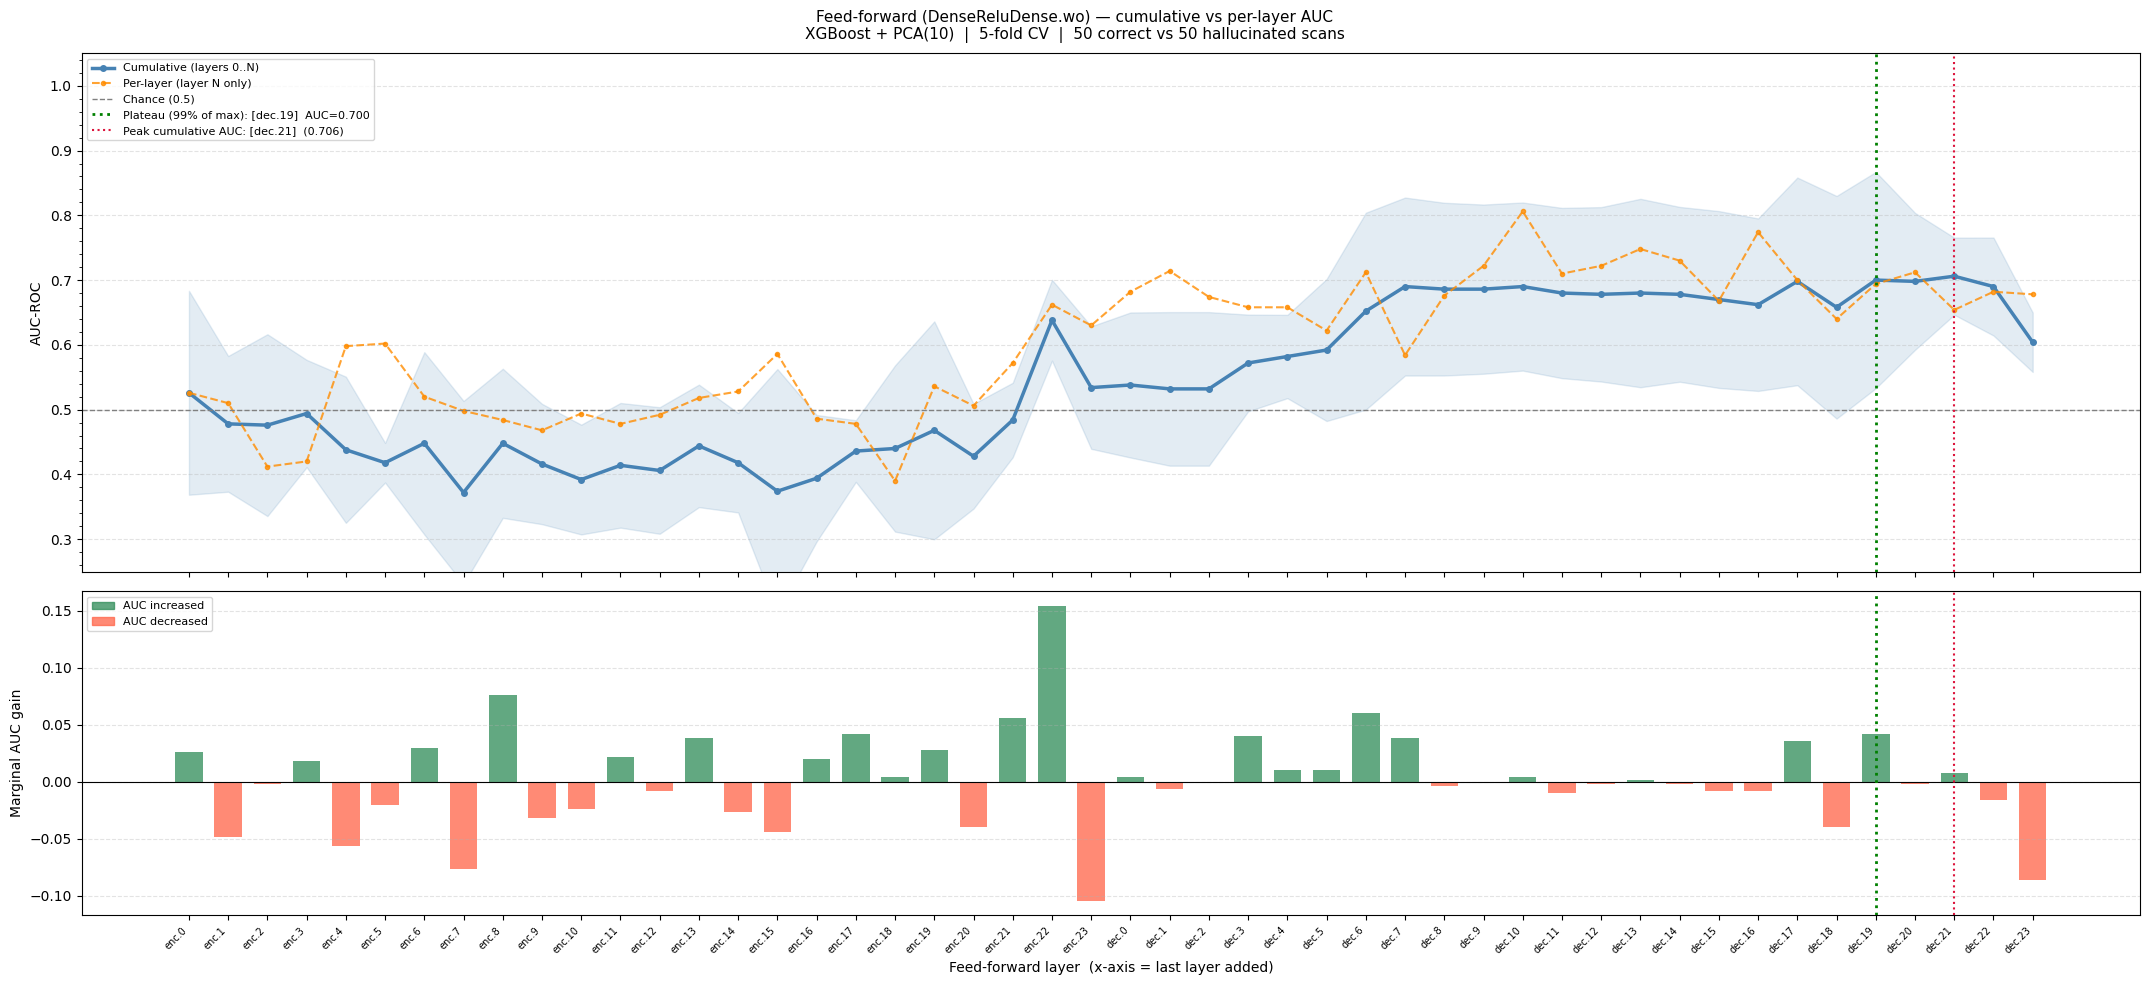


── Feed-forward (DenseReluDense.wo) ──
  Peak cumulative AUC : 0.7060  @ step [45] (up to dec.21)
  Plateau (99% of max): step [43] (up to dec.19)
  Layers needed for plateau: 44 / 48


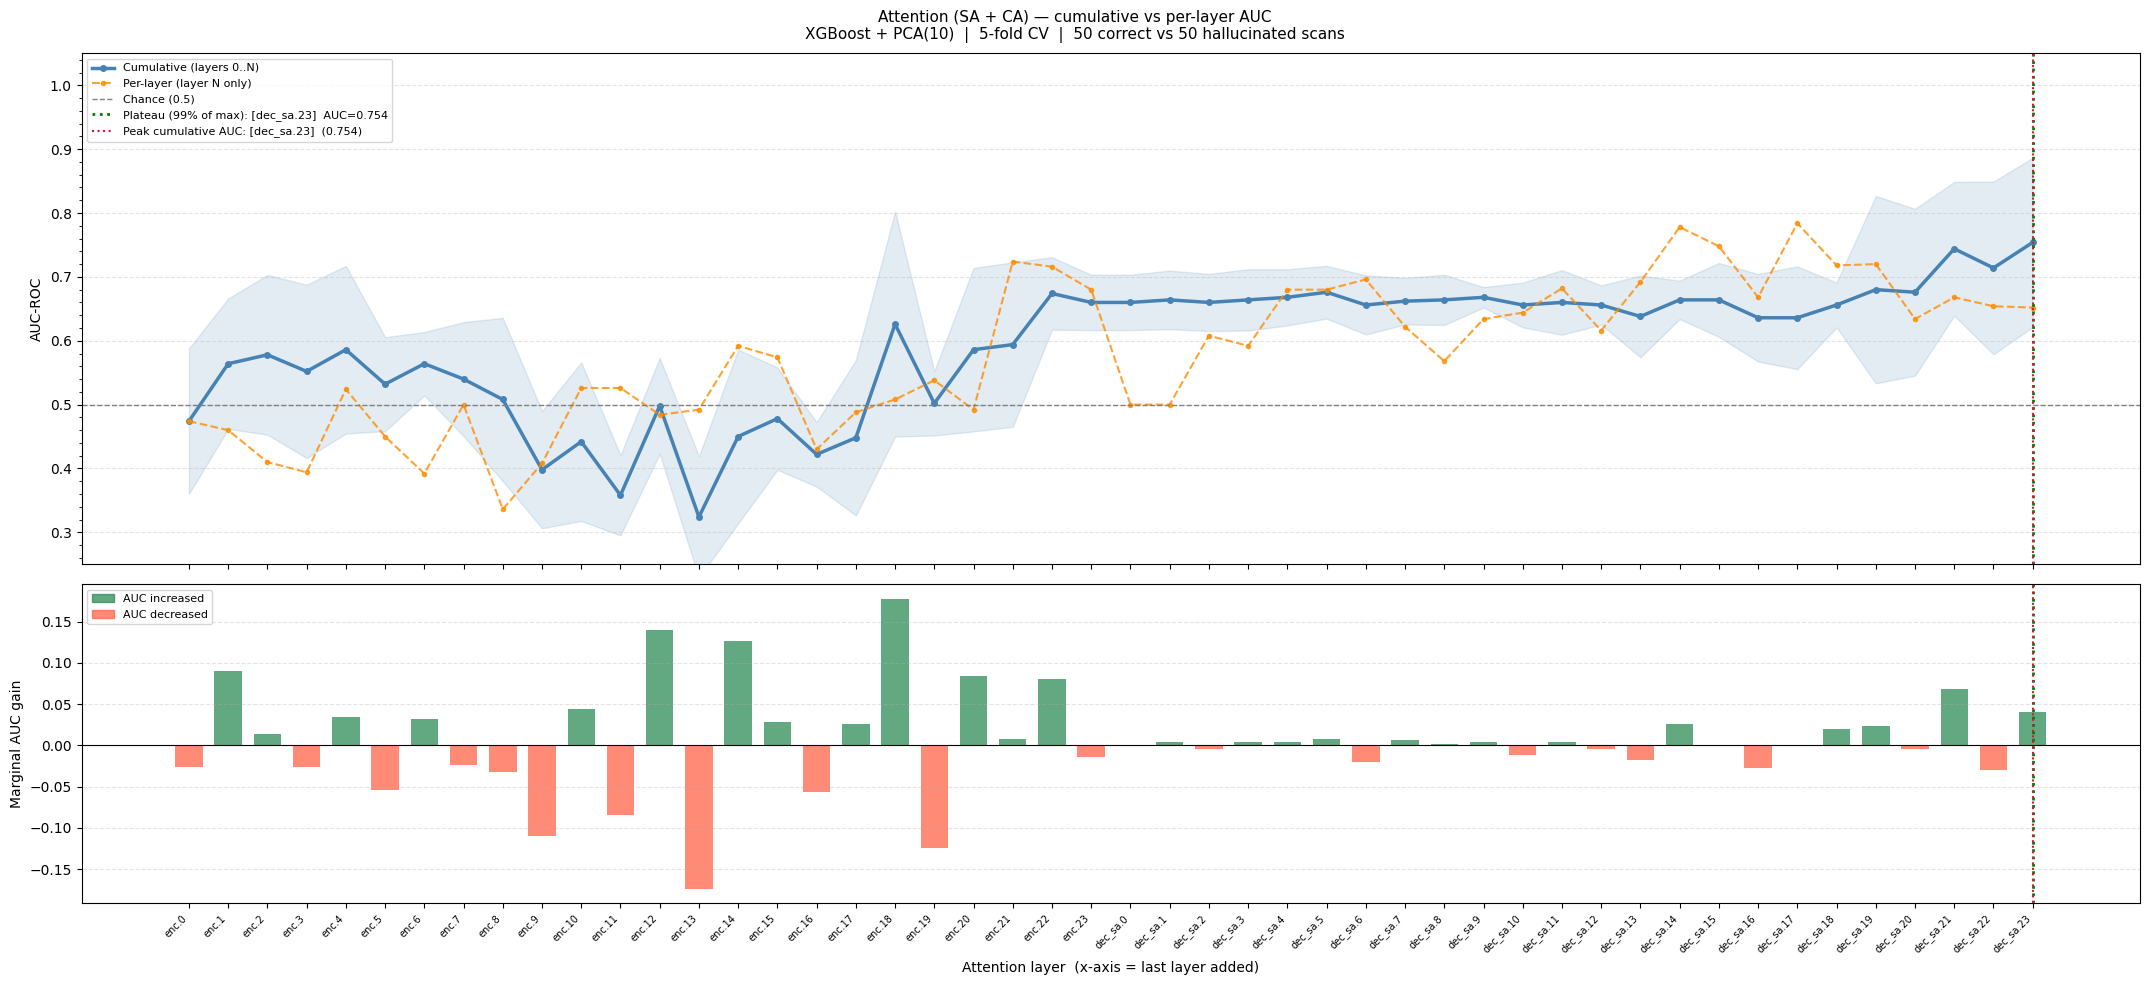


── Attention (SA + CA) ──
  Peak cumulative AUC : 0.7540  @ step [47] (up to dec_sa.23)
  Plateau (99% of max): step [47] (up to dec_sa.23)
  Layers needed for plateau: 48 / 48


In [18]:
def plot_cumulative(per_layer_results, cumulative_results, title_prefix, layer_type_label):
    labels = cumulative_results['labels']
    n      = len(labels)
    x      = np.arange(n)

    cum_auc  = cumulative_results['auc']
    cum_std  = cumulative_results['auc_std']
    solo_auc = per_layer_results['auc']

    best_cum  = int(np.argmax(cum_auc))
    # Plateau: first index where cumulative AUC is within 1% of its eventual max
    plateau_threshold = cum_auc.max() * 0.99
    plateau_idx = next((i for i, a in enumerate(cum_auc) if a >= plateau_threshold), best_cum)

    fig, (ax_auc, ax_delta) = plt.subplots(
        2, 1,
        figsize=(max(14, n * 0.45), 10),
        sharex=True,
        gridspec_kw={'height_ratios': [1.6, 1]},
    )
    fig.suptitle(
        f'{title_prefix} — cumulative vs per-layer AUC\n'
        f'XGBoost + PCA({K_COMPONENTS})  |  {CV_FOLDS}-fold CV  |  '
        f'{GROUP_SIZE} correct vs {GROUP_SIZE} hallucinated scans',
        fontsize=11,
    )

    # ── Top: cumulative AUC vs per-layer AUC ──────────────────────────────────
    ax_auc.fill_between(
        x, cum_auc - cum_std, cum_auc + cum_std,
        alpha=0.15, color='steelblue',
    )
    ax_auc.plot(x, cum_auc,  color='steelblue',  linewidth=2.5,
                marker='o', markersize=4, label='Cumulative (layers 0..N)')
    ax_auc.plot(x, solo_auc, color='darkorange', linewidth=1.5,
                marker='o', markersize=3, linestyle='--', alpha=0.8,
                label='Per-layer (layer N only)')

    ax_auc.axhline(0.5, color='gray', linestyle='--', linewidth=1, label='Chance (0.5)')
    ax_auc.axvline(
        plateau_idx, color='green', linestyle=':', linewidth=2,
        label=f'Plateau (99% of max): [{labels[plateau_idx]}]  AUC={cum_auc[plateau_idx]:.3f}',
    )
    ax_auc.axvline(
        best_cum, color='crimson', linestyle=':', linewidth=1.5,
        label=f'Peak cumulative AUC: [{labels[best_cum]}]  ({cum_auc[best_cum]:.3f})',
    )

    ax_auc.set_ylabel('AUC-ROC')
    ax_auc.set_ylim(0.25, 1.05)
    ax_auc.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax_auc.grid(axis='y', linestyle='--', alpha=0.35)
    ax_auc.legend(fontsize=8, loc='upper left')

    # ── Bottom: marginal AUC gain per added layer ─────────────────────────────
    delta = np.diff(cum_auc, prepend=0.5)   # gain vs previous step (or vs chance at step 0)
    bar_colors = ['seagreen' if d > 0 else 'tomato' for d in delta]
    ax_delta.bar(x, delta, color=bar_colors, alpha=0.75, width=0.7)
    ax_delta.axhline(0, color='black', linewidth=0.8)
    ax_delta.axvline(plateau_idx, color='green',  linestyle=':', linewidth=2)
    ax_delta.axvline(best_cum,    color='crimson', linestyle=':', linewidth=1.5)
    ax_delta.set_ylabel('Marginal AUC gain')
    ax_delta.set_xlabel(f'{layer_type_label}  (x-axis = last layer added)')
    ax_delta.set_xticks(x)
    ax_delta.set_xticklabels(labels, rotation=45, ha='right', fontsize=7)
    ax_delta.grid(axis='y', linestyle='--', alpha=0.35)
    from matplotlib.patches import Patch
    ax_delta.legend(
        handles=[
            Patch(color='seagreen', alpha=0.75, label='AUC increased'),
            Patch(color='tomato',   alpha=0.75, label='AUC decreased'),
        ],
        fontsize=8, loc='upper left',
    )

    plt.tight_layout()
    plt.show()

    print(f'\n── {title_prefix} ──')
    print(f'  Peak cumulative AUC : {cum_auc[best_cum]:.4f}  @ step [{best_cum}] (up to {labels[best_cum]})')
    print(f'  Plateau (99% of max): step [{plateau_idx}] (up to {labels[plateau_idx]})')
    print(f'  Layers needed for plateau: {plateau_idx + 1} / {n}')


plot_cumulative(
    ff_results_sig, ff_cumulative,
    'Feed-forward (DenseReluDense.wo)', 'Feed-forward layer',
)
plot_cumulative(
    attn_results_sig, attn_cumulative,
    'Attention (SA + CA)', 'Attention layer',
)